test

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import itertools
from time import time
import yfinance as yf
from datetime import datetime, timedelta


In [5]:

# Load data for HP Inc. (ticker: HPQ)
ticker = 'HPQ'

# Get today's date in the correct format (YYYY-MM-DD)
today = datetime.now().strftime('%Y-%m-%d')

# Get yesterday's date to avoid weekends and holidays
yesterday = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')

# Download historical data
historical_data = yf.download(ticker, start='2024-11-01', end=yesterday)

# Check if the data is empty
if historical_data.empty:
    print("No data available for the given date range.")
else:
    # Get the most recent closing price and previous closing prices
    if len(historical_data) >= 3:
        close_price = historical_data['Close'].iloc[-1]  # Most recent closing price
        prev_close = historical_data['Close'].iloc[-2]    # Previous closing price
        second_prev_close = historical_data['Close'].iloc[-3]  # Closing price from two periods ago
        print(f"Close price: {close_price}, Previous close: {prev_close}, Second previous close: {second_prev_close}")
    else:
        print("Not enough historical data for calculations.")

[*********************100%***********************]  1 of 1 completed

Close price: Ticker
HPQ    33.639999
Name: 2025-02-14 00:00:00, dtype: float64, Previous close: Ticker
HPQ    33.299999
Name: 2025-02-13 00:00:00, dtype: float64, Second previous close: Ticker
HPQ    33.040001
Name: 2025-02-12 00:00:00, dtype: float64


In [6]:
fv = 36

# Function to calculate first distribution (bids/asks) based on actual or simulated closing price
def calculate_first_distribution(close_price, prev_close, second_prev_close):
    # Calculate bids and asks for each trading type
    f_bid = close_price + 0.2 if close_price < fv else None
    f_ask = close_price - 0.2 if close_price > fv else None

    uc_bid = close_price + 0.2
    dc_ask = close_price - 0.2

    m_bid = close_price + (prev_close - second_prev_close) if second_prev_close < prev_close else None
    m_ask = close_price - (second_prev_close - prev_close) if second_prev_close > prev_close else None

    # Rational Speculator: based on weighted combinations of bids/asks from the first 3 trading types
    weighted_bids = [f_bid, uc_bid, m_bid]
    weighted_asks = [f_ask, dc_ask, m_ask]

    # Print intermediate weighted bids and asks for debugging purposes
    print(f"Weighted Bids: {weighted_bids}")
    print(f"Weighted Asks: {weighted_asks}")

    # Generate different weights and find the closest price to the current closing price
    distributions = np.arange(0.00, 1.02, 0.02)

    # Cartesian product of weights for the three trading types
    weight_combinations = list(itertools.product(distributions, repeat=3))

    # Compute all bid combinations
    bid_combinations = [
        (sum(w * b for w, b in zip(weight_combination, weighted_bids) if b is not None), weight_combination)
        for weight_combination in weight_combinations
    ]

    # Ensure bid_combinations is not empty
    if len(bid_combinations) == 0:
        closest_bid, best_bid_combination = None, None
    else:
        closest_bid, best_bid_combination = min(bid_combinations, key=lambda x: abs(x[0] - close_price))

    # Compute all ask combinations
    weight_combinations = list(itertools.product(distributions, repeat=3))  # Reset iterator
    ask_combinations = [
        (sum(w * a for w, a in zip(weight_combination, weighted_asks) if a is not None), weight_combination)
        for weight_combination in weight_combinations
    ]

    # Ensure ask_combinations is not empty
    if len(ask_combinations) == 0:
        closest_ask, best_ask_combination = None, None
    else:
        closest_ask, best_ask_combination = min(ask_combinations, key=lambda x: abs(x[0] - close_price))

    # Final distribution results
    final_distribution = {
        'Fundamental_Bid': f_bid, 'Fundamental_Ask': f_ask,
        'Cyclical_Bid': uc_bid, 'Cyclical_Ask': dc_ask,
        'Momentum_Bid': m_bid, 'Momentum_Ask': m_ask,
        'Rational_Bid': closest_bid, 'Rational_Ask': closest_ask
    }

    return closest_bid, closest_ask, final_distribution, best_bid_combination, best_ask_combination

In [7]:

# Function to visualize weights, closing prices, and the fundamental value
def plot_weight_distribution_with_closing_price(actual_results):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Format the date axis
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator())

    # Extract data for plotting
    actual_dates = [result['Date'] for result in actual_results]  # Keep it as a list of dates
    closing_prices = [result['Close'] for result in actual_results]

    # Extract weights for bids and asks
    fundamental_bid_weights = [result['Best Bid Weights'][0] for result in actual_results]
    cyclical_bid_weights = [result['Best Bid Weights'][1] for result in actual_results]
    momentum_bid_weights = [result['Best Bid Weights'][2] for result in actual_results]
    
    fundamental_ask_weights = [result['Best Ask Weights'][0] for result in actual_results]
    cyclical_ask_weights = [result['Best Ask Weights'][1] for result in actual_results]
    momentum_ask_weights = [result['Best Ask Weights'][2] for result in actual_results]

    # Plot the weight distributions as stacked bars (bids and asks)
    bar_width = 0.4  # Adjust bar width for better visibility
    x_indices = np.arange(len(actual_dates))  # X positions for each date

    # Bid weights: Stack bids below the x-axis (negative values)
    ax1.bar(x_indices, -np.array(fundamental_bid_weights), width=bar_width, color='green', alpha=0.6, label='Fundamental Bid Weight')
    ax1.bar(x_indices, -np.array(cyclical_bid_weights), width=bar_width, color='blue', alpha=0.6, 
            bottom=-np.array(fundamental_bid_weights), label='Cyclical Bid Weight')
    ax1.bar(x_indices, -np.array(momentum_bid_weights), width=bar_width, color='red', alpha=0.6, 
            bottom=-np.array(fundamental_bid_weights) - np.array(cyclical_bid_weights), label='Momentum Bid Weight')

    # Ask weights: Stack asks above the x-axis (positive values)
    ax1.bar(x_indices, fundamental_ask_weights, width=bar_width, color='green', alpha=0.6, hatch='//', label='Fundamental Ask Weight')
    ax1.bar(x_indices, cyclical_ask_weights, width=bar_width, color='blue', alpha=0.6, 
            bottom=fundamental_ask_weights, hatch='//', label='Cyclical Ask Weight')
    ax1.bar(x_indices, momentum_ask_weights, width=bar_width, color='red', alpha=0.6, 
            bottom=np.array(fundamental_ask_weights) + np.array(cyclical_ask_weights), hatch='//', label='Momentum Ask Weight')

    # Create a y-axis for the closing price and fundamental value
    ax2 = ax1.twinx()
    ax2.plot(x_indices, closing_prices, color='black', linewidth=2, label='Closing Price')
    ax2.axhline(y=fv, color='purple', linestyle='--', linewidth=2, label='Fundamental Value')  # Add fundamental value as a dashed line
    ax2.set_ylabel('Closing Price and Fundamental Value')

    # Set labels and titles
    ax1.set_xticks(x_indices)
    ax1.set_xticklabels([date.strftime('%Y-%m-%d') for date in actual_dates], rotation=45, ha='right')  # Rotate diagonally for better visibility
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Bid and Ask Weights')

    # Set y-axis limits
    ax1.set_ylim(-1.25, 1.25)  # Set left y-axis for bid and ask weights from -1.25 to 1.25
    ax2.set_ylim(25, 40)  # Set right y-axis for closing prices and fundamental value up to 40

    # Add legends back
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    # Add gridlines for better readability
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Show the plot
    plt.title('Weight Distribution, Closing Price, and Fundamental Value Over Time')
    plt.tight_layout()
    plt.show()

In [8]:
# Prepare actual_results based on your historical data
actual_results = []

for i in range(len(historical_data) - 2):
    close_price = historical_data['Close'].iloc[i + 2].item()  # Convert to scalar
    prev_close = historical_data['Close'].iloc[i + 1].item()   # Convert to scalar
    second_prev_close = historical_data['Close'].iloc[i].item()  # Convert to scalar

    # Calculate distributions
    closest_bid, closest_ask, final_distribution, best_bid_combination, best_ask_combination = calculate_first_distribution(
        close_price, prev_close, second_prev_close
    )

    # Append the results
    actual_results.append({
        'Date': historical_data.index[i + 2].date(),
        'Close': close_price,
        'Best Bid Weights': best_bid_combination,
        'Best Ask Weights': best_ask_combination
    })


Weighted Bids: [None, 36.5369369506836, None]
Weighted Asks: [36.13693695068359, 36.13693695068359, 36.049339294433594]
Weighted Bids: [None, 36.80470581054688, 37.249324798583984]
Weighted Asks: [36.40470581054687, 36.40470581054687, None]
Weighted Bids: [None, 37.23114700317383, 37.29891586303711]
Weighted Asks: [36.831147003173825, 36.831147003173825, None]
Weighted Bids: [None, 36.715449523925784, 36.941890716552734]
Weighted Asks: [36.31544952392578, 36.31544952392578, None]
Weighted Bids: [None, 37.55841751098633, None]
Weighted Asks: [37.158417510986325, 37.158417510986325, 36.84272003173828]
Weighted Bids: [None, 37.00305099487305, 37.646018981933594]
Weighted Asks: [36.603050994873044, 36.603050994873044, None]
Weighted Bids: [None, 36.705535125732425, None]
Weighted Asks: [36.30553512573242, 36.30553512573242, 35.95016860961914]
Weighted Bids: [None, 36.388179016113284, None]
Weighted Asks: [35.98817901611328, 35.98817901611328, 35.890663146972656]
Weighted Bids: [None, 36.61

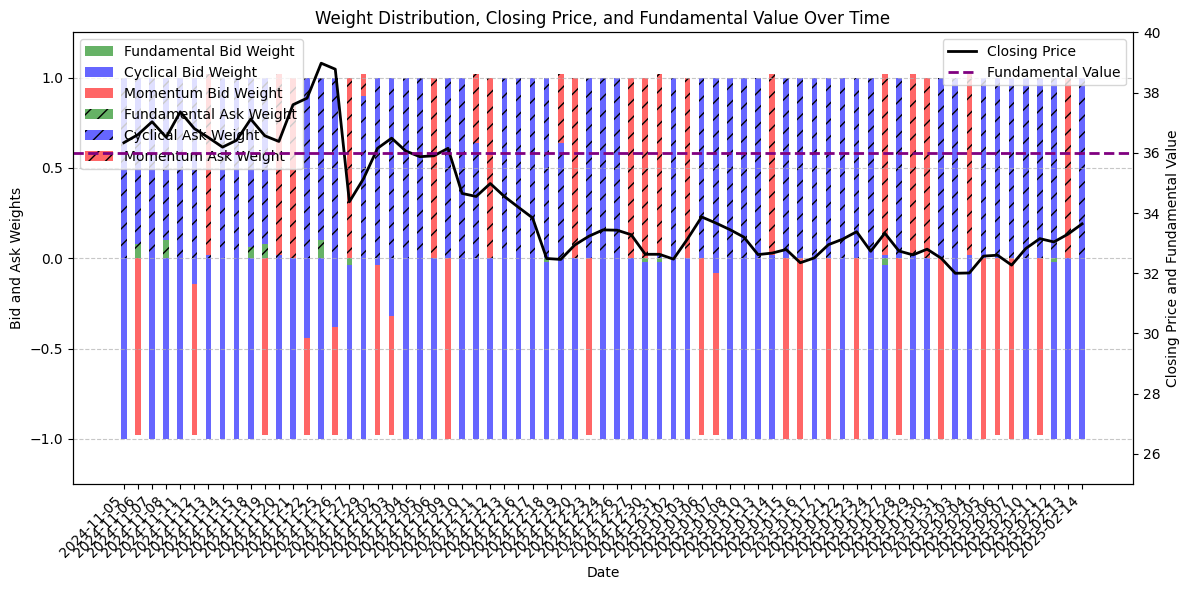

In [9]:
plot_weight_distribution_with_closing_price(actual_results)


In [10]:
def calculate_combined_distribution(close_price, prev_close, second_prev_close):
    # Get closest_bid and closest_ask from the first function
    closest_bid, closest_ask, initial_distribution, best_bid_combination, best_ask_combination = calculate_first_distribution(close_price, prev_close, second_prev_close)


    # Calculate bids and asks for each trading type
    f_bid = close_price + 0.2 if close_price < fv else None
    f_ask = close_price - 0.2 if close_price > fv else None

    uc_bid = close_price + 0.2
    dc_ask = close_price - 0.2

    m_bid = close_price + (prev_close - second_prev_close) if second_prev_close < prev_close else None
    m_ask = close_price - (second_prev_close - prev_close) if second_prev_close > prev_close else None

    # Rational Bid and Ask (from first distribution)
    r_bid = closest_bid if closest_bid < close_price else None
    r_ask = closest_ask if closest_ask > close_price else None 

    # Based on weighted combinations of bids/asks from all trading types
    weighted_bids = [f_bid, uc_bid, m_bid, r_bid]  
    weighted_asks = [f_ask, dc_ask, m_ask, r_ask]   

    # Generate different weights and find the closest price to the current closing price
    distributions = np.arange(0.00, 1.02, 0.02)

    # Cartesian product of weights for the four trading types
    weight_combinations = list(itertools.product(distributions, repeat=4))

    # Compute all bid combinations
    bid_combinations = [
        (sum(w * b for w, b in zip(weight_combination, weighted_bids) if b is not None), weight_combination)
        for weight_combination in weight_combinations
    ]

  # Ensure bid_combinations is not empty
    if len(bid_combinations) == 0:
        closest_bid, best_bid_combination = None, None
    else:
        closest_bid, best_bid_combination = min(bid_combinations, key=lambda x: abs(x[0] - close_price))

    # Compute all ask combinations
    weight_combinations = list(itertools.product(distributions, repeat=4))  # Reset iterator
    ask_combinations = [
        (sum(w * a for w, a in zip(weight_combination, weighted_asks) if a is not None), weight_combination)
        for weight_combination in weight_combinations
    ]

    # Ensure ask_combinations is not empty
    if len(ask_combinations) == 0:
        closest_ask, best_ask_combination = None, None
    else:
        closest_ask, best_ask_combination = min(ask_combinations, key=lambda x: abs(x[0] - close_price))

    # Final distribution results
    final_distribution = {
        'Fundamental_Bid': f_bid, 'Fundamental_Ask': f_ask,
        'Cyclical_Bid': uc_bid, 'Cyclical_Ask': dc_ask,
        'Momentum_Bid': m_bid, 'Momentum_Ask': m_ask,
        'Rational_Bid': r_bid, 'Rational_Ask': r_ask
    }

    return closest_bid, closest_ask, final_distribution, best_bid_combination, best_ask_combination

In [11]:
# Prepare actual_results based on your historical data
results = []

for i in range(len(historical_data) - 2):
    close_price = historical_data['Close'].iloc[i + 2].item()  # Convert to scalar
    prev_close = historical_data['Close'].iloc[i + 1].item()  # Convert to scalar
    second_prev_close = historical_data['Close'].iloc[i].item()  # Convert to scalar

    # Calculate distributions
    closest_bid, closest_ask, final_distribution, best_bid_combination, best_ask_combination = calculate_combined_distribution(
        close_price, prev_close, second_prev_close
    )

    # Append the results
    results.append({
        'Date': historical_data.index[i + 2].date(),
        'Close': close_price,
        'Best Bid Weights': best_bid_combination,
        'Best Ask Weights': best_ask_combination
    })


Weighted Bids: [None, 36.5369369506836, None]
Weighted Asks: [36.13693695068359, 36.13693695068359, 36.049339294433594]
Weighted Bids: [None, 36.80470581054688, 37.249324798583984]
Weighted Asks: [36.40470581054687, 36.40470581054687, None]
Weighted Bids: [None, 37.23114700317383, 37.29891586303711]
Weighted Asks: [36.831147003173825, 36.831147003173825, None]
Weighted Bids: [None, 36.715449523925784, 36.941890716552734]
Weighted Asks: [36.31544952392578, 36.31544952392578, None]
Weighted Bids: [None, 37.55841751098633, None]
Weighted Asks: [37.158417510986325, 37.158417510986325, 36.84272003173828]
Weighted Bids: [None, 37.00305099487305, 37.646018981933594]
Weighted Asks: [36.603050994873044, 36.603050994873044, None]
Weighted Bids: [None, 36.705535125732425, None]
Weighted Asks: [36.30553512573242, 36.30553512573242, 35.95016860961914]
Weighted Bids: [None, 36.388179016113284, None]
Weighted Asks: [35.98817901611328, 35.98817901611328, 35.890663146972656]
Weighted Bids: [None, 36.61

In [12]:
def plot_combined_weight_distribution_with_closing_price(actual_results):
    """
    Plots bid and ask weights for four trading types (Fundamental, Cyclical, Momentum, Rational)
    and overlays the closing price with the fundamental value on a secondary axis.
    """
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Format the date axis
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator())

    # Extract data for plotting
    actual_dates = [result['Date'] for result in actual_results]  # Keep it as a list of dates
    closing_prices = [result['Close'] for result in actual_results]

    # Extract weights for Fundamental, Cyclical, Momentum, Rational Bids
    fundamental_bid_weights = [res['Best Bid Weights'][0] for res in actual_results if len(res['Best Bid Weights']) >= 4]
    cyclical_bid_weights    = [res['Best Bid Weights'][1] for res in actual_results if len(res['Best Bid Weights']) >= 4]
    momentum_bid_weights    = [res['Best Bid Weights'][2] for res in actual_results if len(res['Best Bid Weights']) >= 4]
    rational_bid_weights    = [res['Best Bid Weights'][3] for res in actual_results if len(res['Best Bid Weights']) >= 4]

    # Extract weights for Fundamental, Cyclical, Momentum, Rational Asks
    fundamental_ask_weights = [res['Best Ask Weights'][0] for res in actual_results if len(res['Best Ask Weights']) >= 4]
    cyclical_ask_weights    = [res['Best Ask Weights'][1] for res in actual_results if len(res['Best Ask Weights']) >= 4]
    momentum_ask_weights    = [res['Best Ask Weights'][2] for res in actual_results if len(res['Best Ask Weights']) >= 4]
    rational_ask_weights    = [res['Best Ask Weights'][3] for res in actual_results if len(res['Best Ask Weights']) >= 4]

    # The number of valid data points that have all four weights
    x_count = len(fundamental_bid_weights)
    x_indices = np.arange(x_count)

    # Adjust bar width for better visibility
    bar_width = 0.4

    # ------------------------
    # Plot Bids Below the x-axis
    # ------------------------
    # Fundamental Bids
    ax1.bar(
        x_indices,
        -np.array(fundamental_bid_weights),
        width=bar_width,
        color='green',
        alpha=0.6,
        label='Fundamental Bid Weight'
    )

    # Cyclical Bids (stacked on top of fundamental)
    ax1.bar(
        x_indices,
        -np.array(cyclical_bid_weights),
        width=bar_width,
        color='blue',
        alpha=0.6,
        bottom=-np.array(fundamental_bid_weights),
        label='Cyclical Bid Weight'
    )

    # Momentum Bids (stacked on top of fundamental + cyclical)
    ax1.bar(
        x_indices,
        -np.array(momentum_bid_weights),
        width=bar_width,
        color='red',
        alpha=0.6,
        bottom=-np.array(fundamental_bid_weights) - np.array(cyclical_bid_weights),
        label='Momentum Bid Weight'
    )

    # Rational Bids (stacked on top of fundamental + cyclical + momentum)
    ax1.bar(
        x_indices,
        -np.array(rational_bid_weights),
        width=bar_width,
        color='black',
        alpha=0.6,
        bottom=(
            -np.array(fundamental_bid_weights)
            - np.array(cyclical_bid_weights)
            - np.array(momentum_bid_weights)
        ),
        label='Rational Bid Weight'
    )

    # ------------------------
    # Plot Asks Above the x-axis
    # ------------------------
    # Fundamental Asks
    ax1.bar(
        x_indices,
        fundamental_ask_weights,
        width=bar_width,
        color='green',
        alpha=0.6,
        hatch='//',
        label='Fundamental Ask Weight'
    )

    # Cyclical Asks (stacked on top of fundamental)
    ax1.bar(
        x_indices,
        cyclical_ask_weights,
        width=bar_width,
        color='blue',
        alpha=0.6,
        bottom=fundamental_ask_weights,
        hatch='//',
        label='Cyclical Ask Weight'
    )

    # Momentum Asks (stacked on top of fundamental + cyclical)
    ax1.bar(
        x_indices,
        momentum_ask_weights,
        width=bar_width,
        color='red',
        alpha=0.6,
        bottom=np.array(fundamental_ask_weights) + np.array(cyclical_ask_weights),
        hatch='//',
        label='Momentum Ask Weight'
    )

    # Rational Asks (stacked on top of fundamental + cyclical + momentum)
    ax1.bar(
        x_indices,
        rational_ask_weights,
        width=bar_width,
        color='black',
        alpha=0.6,
        bottom=(
            np.array(fundamental_ask_weights)
            + np.array(cyclical_ask_weights)
            + np.array(momentum_ask_weights)
        ),
        hatch='//',
        label='Rational Ask Weight'
    )

    # ------------------------
    # Create a second y-axis for the closing price
    # ------------------------
    ax2 = ax1.twinx()

    # Plot the closing prices (ensure we match the x_indices length if needed)
    # If actual_dates had more points than x_count, we slice or handle it carefully
    ax2.plot(
        x_indices,
        closing_prices[:x_count],
        color='black',
        linewidth=2,
        label='Closing Price'
    )

    # Plot the fundamental value line
    ax2.axhline(
        y=fv,
        color='purple',
        linestyle='--',
        linewidth=2,
        label='Fundamental Value'
    )
    ax2.set_ylabel('Closing Price and Fundamental Value')

    # ------------------------
    # Format axes
    # ------------------------
    # Format x-axis with dates
    ax1.set_xticks(x_indices)
    # Show only those date labels that correspond to the valid 4-weight combos
    limited_dates = [actual_dates[j] for j in range(x_count)]
    ax1.set_xticklabels([d.strftime('%Y-%m-%d') for d in limited_dates], rotation=45, ha='right')

    ax1.set_xlabel('Date')
    ax1.set_ylabel('Bid and Ask Weights')

    # Y-axis limits
    ax1.set_ylim(-1.25, 1.25)
    ax2.set_ylim(25, 40)

    # Legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    # Gridlines on the primary y-axis
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Title and layout
    plt.title('Weight Distribution, Closing Price, and Fundamental Value Over Time')
    plt.tight_layout()
    plt.show()


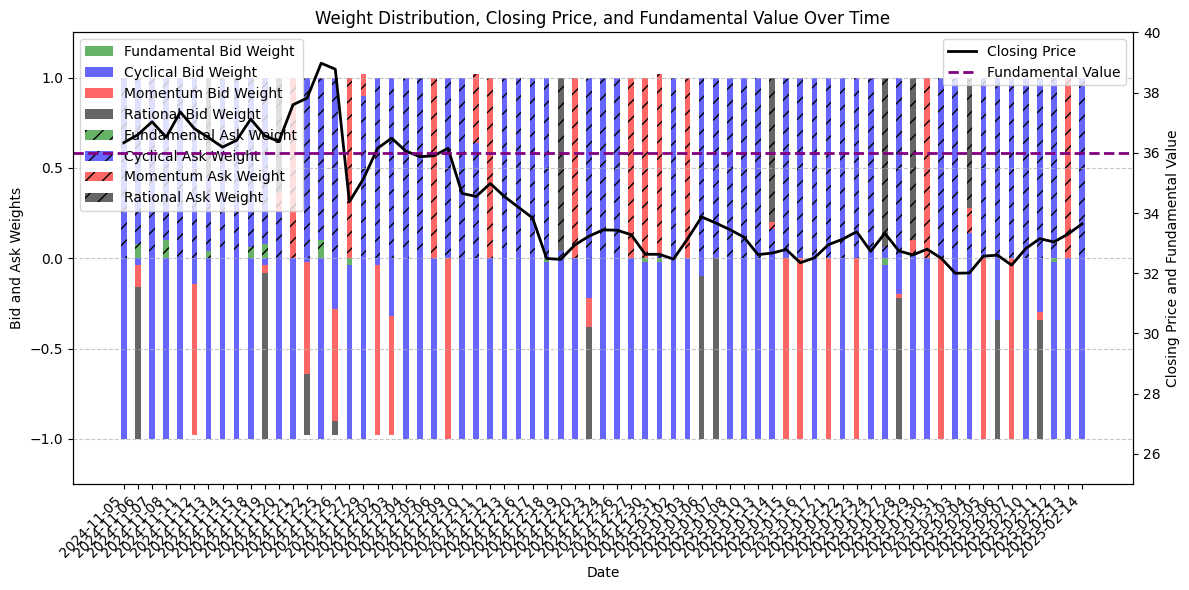

In [13]:

# Plot the weight distribution and closing prices
plot_combined_weight_distribution_with_closing_price(results)





---

## Following code will try to simulate the **market mechanism** with the TT distibution found above and thereby derive next periods price. By repeating the simulations on the derived prices, a **price pattern** should be generated and compared to the actual price pattern 


The question here arises, that if I design the market mechansim function with the volumne, then its ambigous which volumne I use for the simulation days 

My issue is that the **simulate_based_on_historical_data** function can not be as easily acessed with the **simulate_future_prices** to simulate continuing from the historic simulation with the **calculate_combined_distribution** funtion 

**for now we focus on the rational speculator daily forcasts before we try to incorporate them in the model** 

In [20]:
def simulate_market_with_volume(bids, asks):
    """
    Simulate market interactions, matching bids and asks based on price and volume.
    If highest_bid >= lowest_ask, the trade occurs at the ask price.
    
    Parameters:
    - bids: list of (bid_price, bid_volume)
    - asks: list of (ask_price, ask_volume)
    
    Returns:
    - final_price: The price of the last successful transaction.
    """
    # Sort bids descending by price, asks ascending by price
    matched_bids = sorted(bids, key=lambda x: x[0], reverse=True)   # Highest to lowest
    matched_asks = sorted(asks, key=lambda x: x[0])                 # Lowest to highest
    
    final_price = None  # Keep track of the last price at which a trade occurred

    # While there are still bids and asks
    while matched_bids and matched_asks:
        best_bid_price, best_bid_volume = matched_bids[0]
        best_ask_price, best_ask_volume = matched_asks[0]

        # Check for a transaction
        if best_bid_price >= best_ask_price:
            # According to your rule: trade occurs at the ask price
            transaction_price = best_ask_price
            
            # Determine how many shares/units can change hands
            traded_volume = min(best_bid_volume, best_ask_volume)
            final_price = transaction_price  # The last trade price is the ask

            # Update volumes
            best_bid_volume -= traded_volume
            best_ask_volume -= traded_volume

            # Remove or update exhausted orders
            if best_bid_volume == 0:
                matched_bids.pop(0)  # This bid is fully filled
            else:
                matched_bids[0] = (best_bid_price, best_bid_volume)

            if best_ask_volume == 0:
                matched_asks.pop(0)  # This ask is fully filled
            else:
                matched_asks[0] = (best_ask_price, best_ask_volume)

        else:
            # No trade if the best bid is below the best ask
            break

    return final_price
